<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 13 </b></center>
<pre>    

## Step 1: Import Necessary Libraries
complete the import statements below.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

## Step 2: Load the Dataset
Load the dataset (e.g., Iris dataset) or use your own.

In [2]:
iris = load_iris()

In [3]:
X = iris.data
y = iris.target

## Step 3: Preprocess the Data (Standardization)
Standardize the dataset before applying PCA or LDA.

In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [5]:
X_scaled[:, 1]

array([ 1.01900435, -0.13197948,  0.32841405,  0.09821729,  1.24920112,
        1.93979142,  0.78880759,  0.78880759, -0.36217625,  0.09821729,
        1.47939788,  0.78880759, -0.13197948, -0.13197948,  2.16998818,
        3.09077525,  1.93979142,  1.01900435,  1.70959465,  1.70959465,
        0.78880759,  1.47939788,  1.24920112,  0.55861082,  0.78880759,
       -0.13197948,  0.78880759,  1.01900435,  0.78880759,  0.32841405,
        0.09821729,  0.78880759,  2.40018495,  2.63038172,  0.09821729,
        0.32841405,  1.01900435,  1.24920112, -0.13197948,  0.78880759,
        1.01900435, -1.74335684,  0.32841405,  1.01900435,  1.70959465,
       -0.13197948,  1.70959465,  0.32841405,  1.47939788,  0.55861082,
        0.32841405,  0.32841405,  0.09821729, -1.74335684, -0.59237301,
       -0.59237301,  0.55861082, -1.51316008, -0.36217625, -0.82256978,
       -2.43394714, -0.13197948, -1.97355361, -0.36217625, -0.36217625,
        0.09821729, -0.13197948, -0.82256978, -1.97355361, -1.28

## Step 4: Apply PCA
Perform PCA and extract the principal components.

In [6]:
pca = PCA(n_components = 0.95)
X_pca = pca.fit_transform(X_scaled)

In [7]:
X_pca.shape

(150, 2)

## Step 5: Visualization
Visualize PCA results using scatter plots.

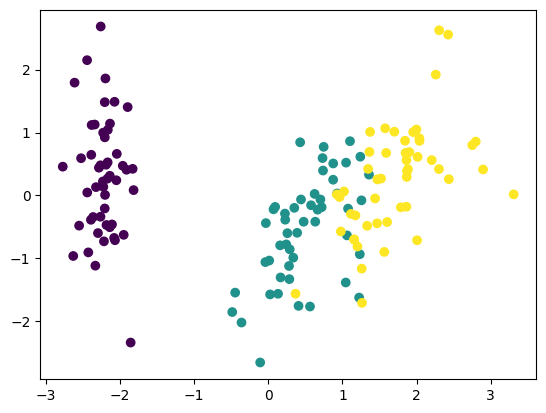

In [8]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c = y)
plt.show()

## Train the model using above data 

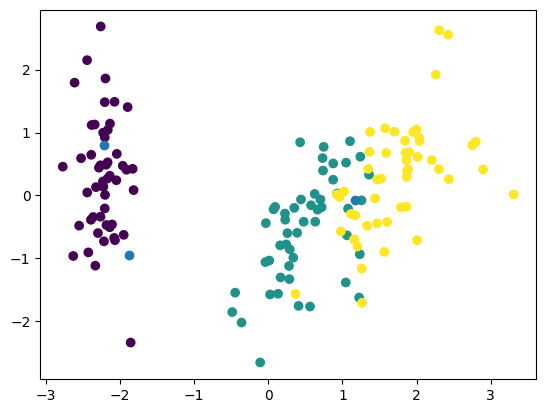

In [9]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 3, random_state = 42)
kmeans_labels = kmeans.fit_predict(X_pca)

centerdata = kmeans.cluster_centers_

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.scatter(centerdata[:, 0], centerdata[:, 1])
plt.show()

## Step 6: Feature Selection using Filter Methods
In this section, you will apply different filter methods such as:
- **Pearson Correlation Coefficient**
- **Chi-Square Test**
- **Variance Thresholding**

### 8.1 Pearson Correlation Coefficient
Calculate the correlation between features and the target variable.

In [10]:
import seaborn as sns

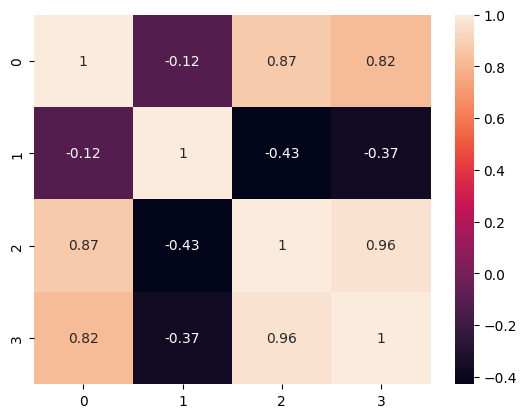

In [11]:
correlation_matrix = np.corrcoef(X_scaled.T)
sns.heatmap(correlation_matrix, annot=True)
plt.show()

### 8.2 Chi-Square Test
Use the Chi-Square test to determine the relationship between features and the target variable.

In [12]:
from sklearn.feature_selection import chi2

In [13]:
chi2(X, y)

(array([ 10.81782088,   3.7107283 , 116.31261309,  67.0483602 ]),
 array([4.47651499e-03, 1.56395980e-01, 5.53397228e-26, 2.75824965e-15]))

### 8.3 Variance Thresholding
Remove features with low variance as they may not be useful for predictions.

## Step 9: Feature Selection using Wrapper Methods
Wrapper methods evaluate feature subsets based on model performance.
In this section, we will use:
- **Recursive Feature Elimination (RFE)**
- **Sequential Feature Selection (SFS)**

### 9.1 Recursive Feature Elimination (RFE)
RFE removes the least important features iteratively until the optimal subset is reached.

### 9.2 Sequential Feature Selection (SFS)
SFS iteratively selects the best-performing features by adding or removing them.

## Step 10: Applying PCA on Digits Dataset
In this section, we will apply PCA on the `load_digits` dataset, which consists of handwritten digit images, and visualize its effect.

### 10.1 Load and Visualize the Digits Dataset
We will load the dataset and visualize some sample images.

In [14]:
from sklearn.datasets import load_digits

In [15]:
digits = load_digits()

X_digits = digits.data
y_digits = digits.target

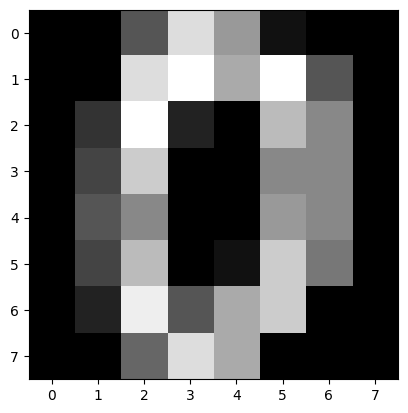

In [25]:
plt.imshow(digits.images[0], cmap ='gray')

### 10.2 Apply PCA and Reduce Dimensions
We will reduce the dataset to 2 principal components and visualize the transformed data.

In [26]:
pca_digits = PCA(n_components = 2)
X_pca_digits = pca_digits.fit_transform(X_digits, y_digits)

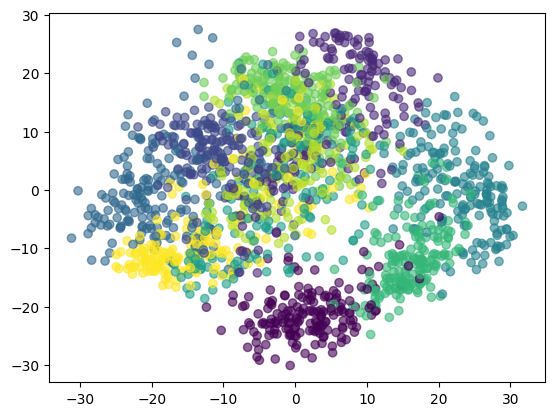

In [27]:
plt.scatter(X_pca_digits[:, 0], X_pca_digits[:, 1], c = y_digits, alpha = 0.6)
plt.show()